<a href="https://colab.research.google.com/github/Subi-003/Credit-Risk-Analysis-/blob/main/Credit_Risk_Modelling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

PROBLEM STATEMENT:

Banks and lenders need to decide who to grant credit to. Manually reviewing every application is slow therefore, a model that flags high-risk applicants reduces financial losses from defaults.

DATASET:

*   9 features: Age, Sex, Job, Housing, Saving accounts, Checking account, Credit amount, Duration, Purpose
*   1 target: Risk (good / bad)





In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("https://raw.githubusercontent.com/Subi-003/Credit-Risk-Analysis-/refs/heads/main/german_credit_data.csv")

In [3]:
df.shape

(1000, 11)

In [4]:
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


In [5]:
df.dtypes

,0
Unnamed: 0,int64
Age,int64
Sex,object
Job,int64
Housing,object
Saving accounts,object
Checking account,object
Credit amount,int64
Duration,int64
Purpose,object


In [6]:
df.isnull().sum()

,0
Unnamed: 0,0
Age,0
Sex,0
Job,0
Housing,0
Saving accounts,183
Checking account,394
Credit amount,0
Duration,0
Purpose,0


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df=df.dropna().reset_index(drop=True)

In [9]:
df['Age'].describe()

,Age
count,522.000000
mean,34.888889
std,11.787918
min,19.000000
25%,26.000000
50%,31.500000
75%,41.000000
max,75.000000


In [10]:
df['Risk'].value_counts()

,count
Risk,
good,291
bad,231


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 522 entries, 0 to 521
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        522 non-null    int64 
 1   Age               522 non-null    int64 
 2   Sex               522 non-null    object
 3   Job               522 non-null    int64 
 4   Housing           522 non-null    object
 5   Saving accounts   522 non-null    object
 6   Checking account  522 non-null    object
 7   Credit amount     522 non-null    int64 
 8   Duration          522 non-null    int64 
 9   Purpose           522 non-null    object
 10  Risk              522 non-null    object
dtypes: int64(5), object(6)
memory usage: 45.0+ KB


In [12]:
df['Job'].unique()

array([2, 3, 1, 0])

In [13]:
df.columns

Index(['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts',
       'Checking account', 'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

In [14]:
df.drop(columns='Unnamed: 0',inplace=True)

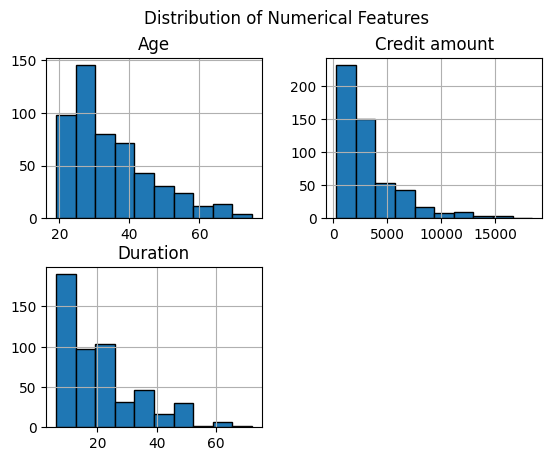

In [15]:
df[['Age','Credit amount','Duration']].hist(bins=10,edgecolor='black')
plt.suptitle('Distribution of Numerical Features')
plt.show()

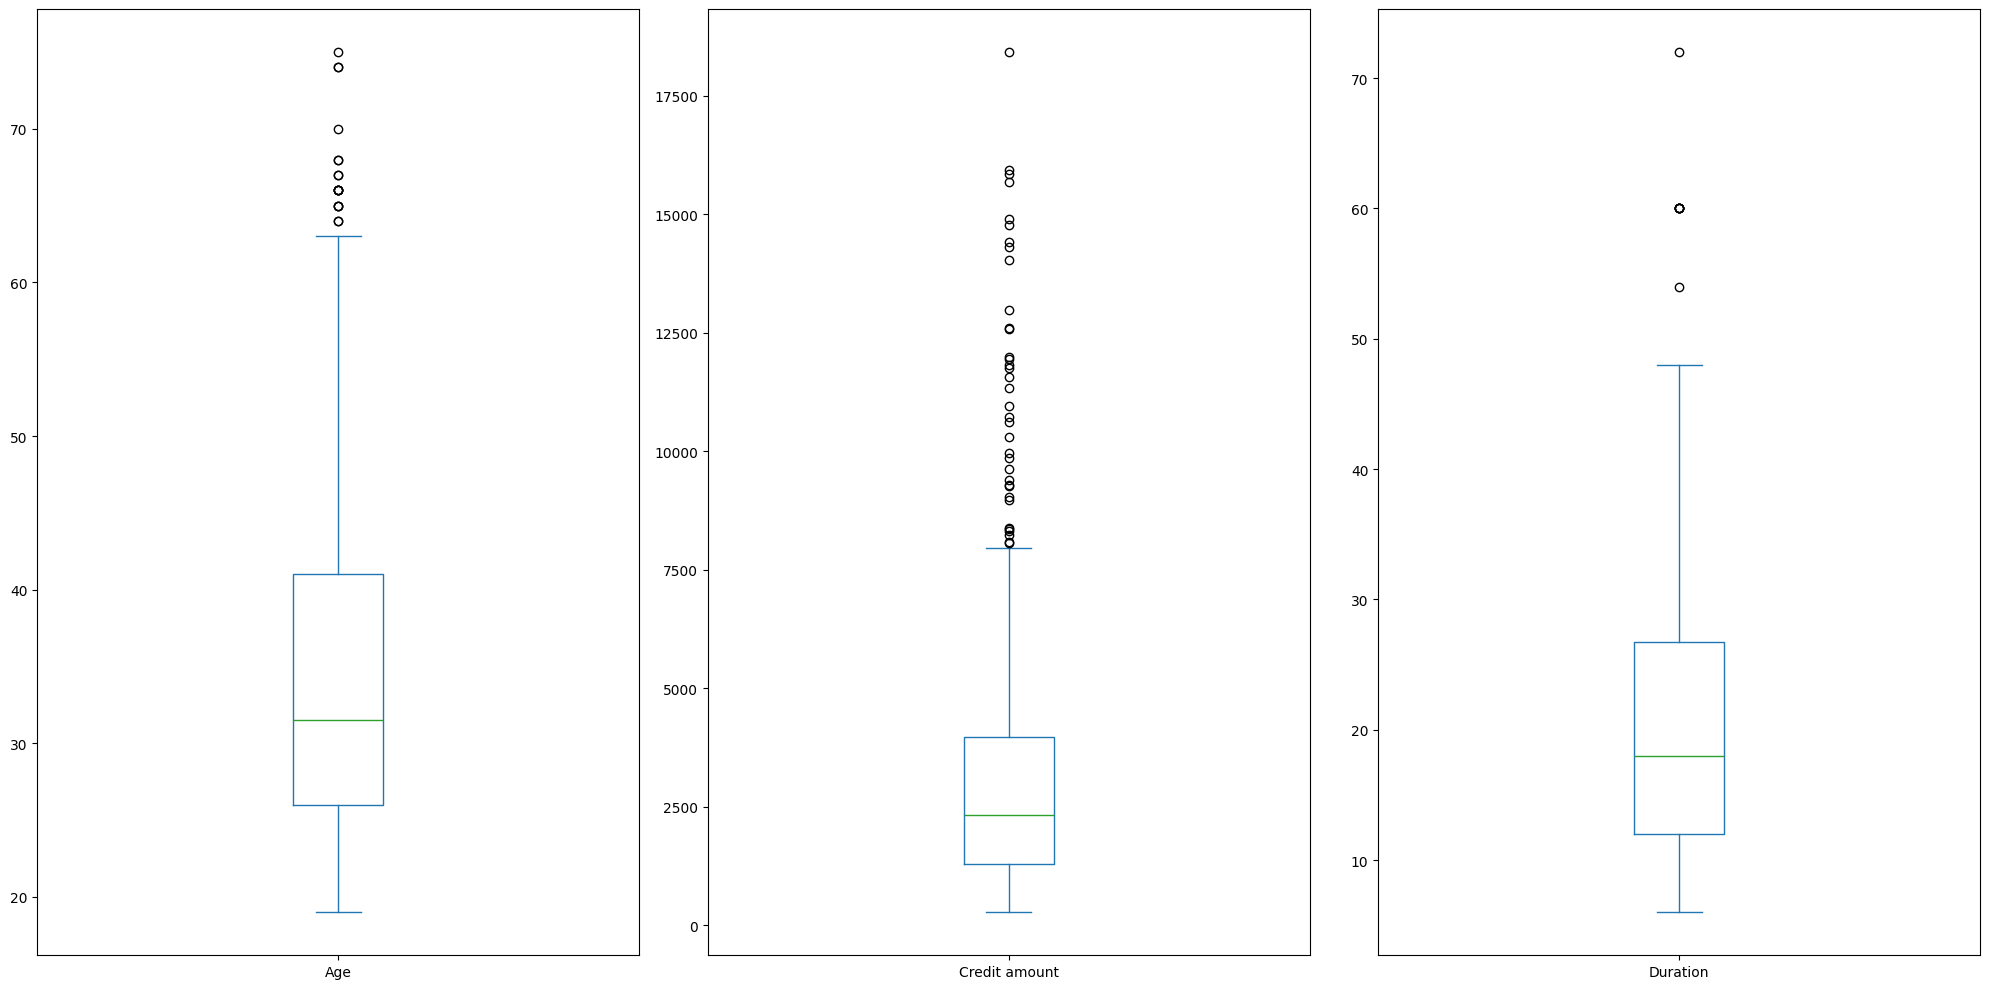

In [16]:
df[["Age", "Credit amount", "Duration"]].plot(
    kind="box",
    subplots=True,
    layout=(1, 3),
    figsize=(20, 10)
)
plt.tight_layout()
plt.show()

In [17]:
df.query('Duration >= 60')

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
18,63,male,2,own,little,little,6836,60,business,bad
176,24,female,3,own,moderate,moderate,7408,60,car,bad
199,60,female,3,free,moderate,moderate,14782,60,vacation/others,bad
358,24,male,2,own,moderate,moderate,5595,72,radio/TV,bad
378,27,male,3,own,little,moderate,14027,60,car,bad
489,42,male,2,free,little,moderate,6288,60,education,bad
507,36,male,2,rent,little,little,7297,60,business,bad


In [18]:
cat_cols=['Sex','Housing','Saving accounts','Checking account','Purpose']

In [19]:
df[cat_cols].describe()

,Sex,Housing,Saving accounts,Checking account,Purpose
count,522,522,522,522,522
unique,2,3,4,3,8
top,male,own,little,little,car
freq,354,349,412,245,173


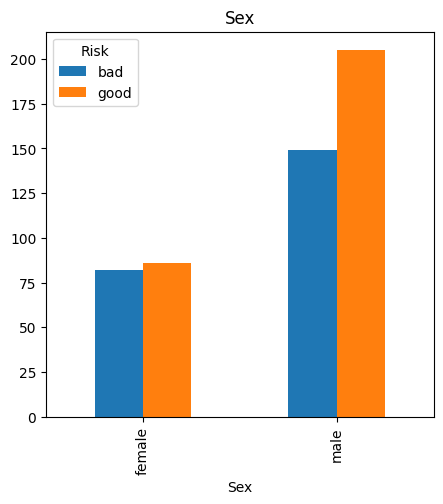

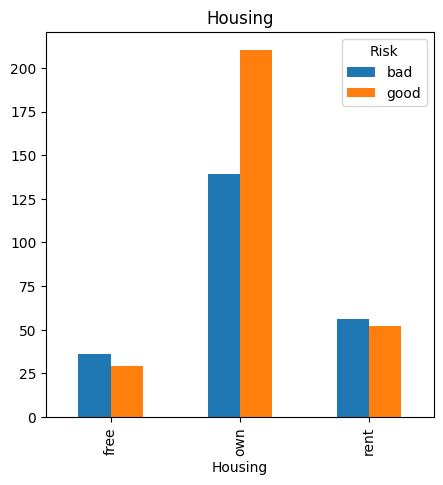

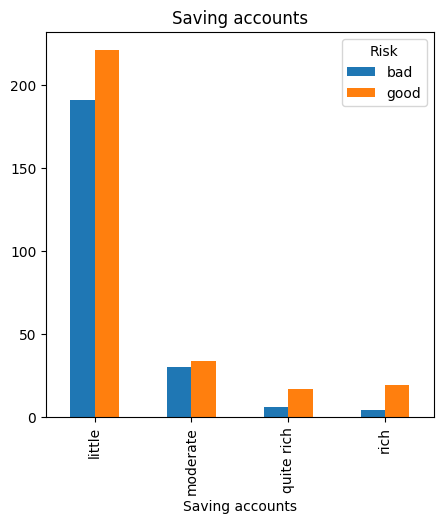

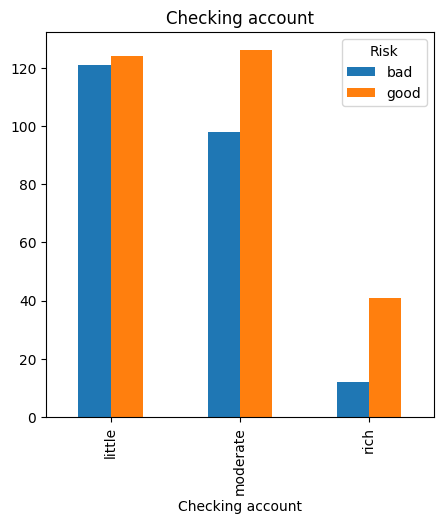

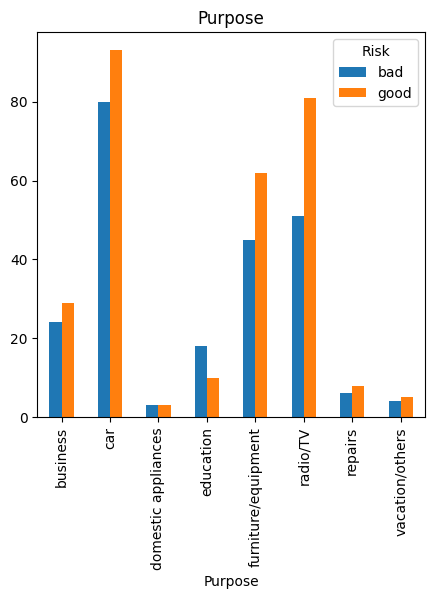

In [20]:
for col in cat_cols:
    df.groupby(col)['Risk'].value_counts().unstack().plot(kind='bar', figsize=(5,5), title=col)
    plt.show()

In [21]:
num_cols=df[['Age','Job','Credit amount','Duration']]

In [22]:
corr=num_cols.corr()
corr

,Age,Job,Credit amount,Duration
Age,1.000000,0.039771,0.082014,0.001549
Job,0.039771,1.000000,0.334721,0.200794
Credit amount,0.082014,0.334721,1.000000,0.613298
Duration,0.001549,0.200794,0.613298,1.000000


In [23]:
df.groupby('Job')['Credit amount'].mean()

,Credit amount
Job,
0,1767.857143
1,2250.715517
2,3129.130990
3,5648.784810


In [24]:
pd.pivot_table(df, values='Credit amount', index='Housing', columns='Purpose')

Purpose,business,car,domestic appliances,education,furniture/equipment,radio/TV,repairs,vacation/others
Housing,,,,,,,,
free,4705.000000,5180.314286,NaN,5314.250000,4419.444444,2097.000000,1190.0,7842.666667
own,3725.973684,3120.485437,1333.5,2625.076923,3031.100000,2307.613861,2993.5,10321.833333
rent,6180.833333,3398.285714,NaN,2627.857143,2890.285714,2138.000000,2384.0,NaN


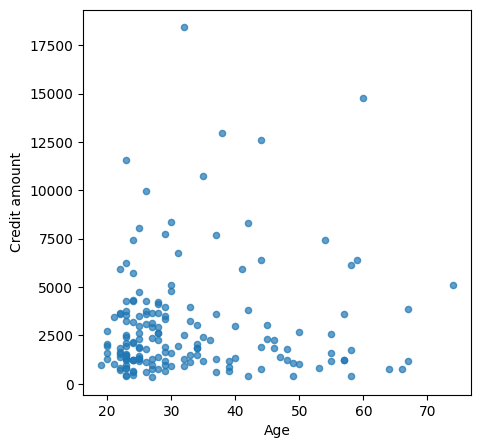

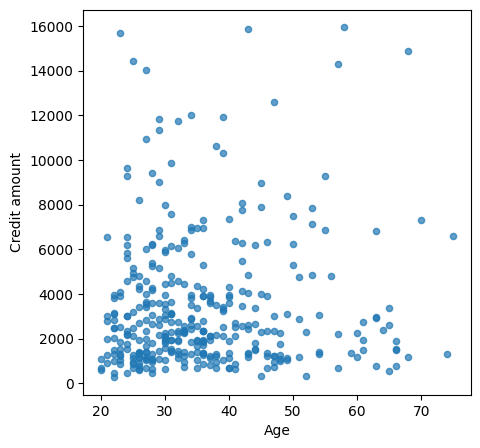

In [25]:
df.groupby('Sex').plot.scatter(x='Age', y='Credit amount', figsize=(5,5),alpha=0.7)
plt.show()

In [26]:
df['Risk'].value_counts(normalize=True)*100

,proportion
Risk,
good,55.747126
bad,44.252874


In [27]:
df.groupby('Risk')[['Age','Credit amount','Duration']].mean()

,Age,Credit amount,Duration
Risk,,,
bad,34.147186,3881.090909,25.445887
good,35.477663,2800.594502,18.079038


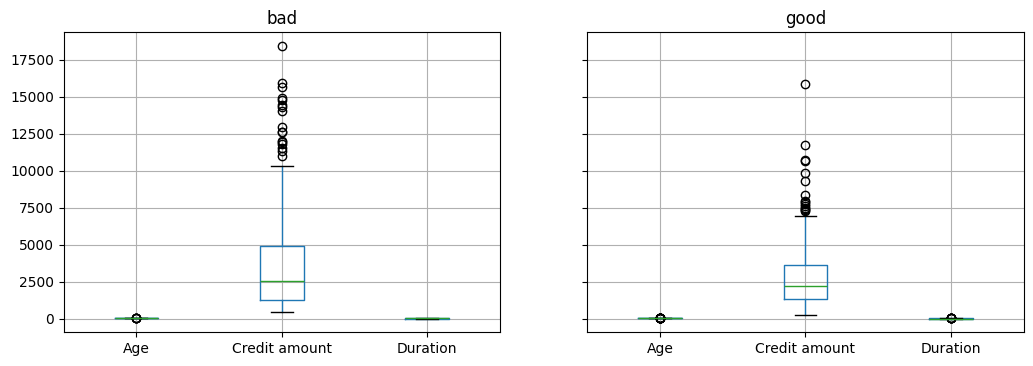

In [28]:
df.groupby('Risk')[['Age', 'Credit amount', 'Duration']].boxplot(figsize=(12, 4))
plt.show()

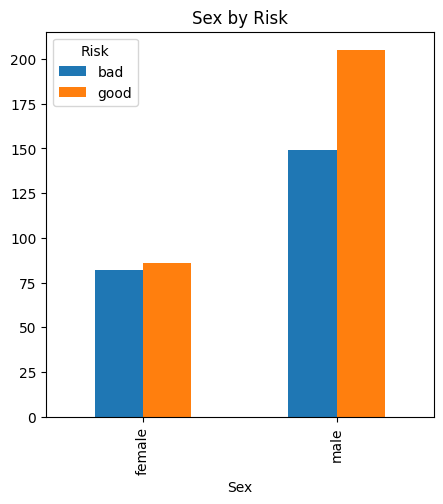

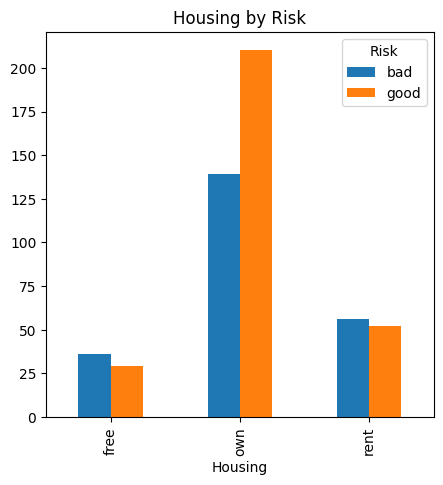

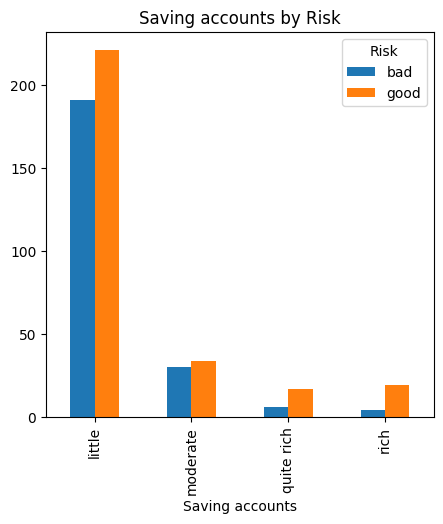

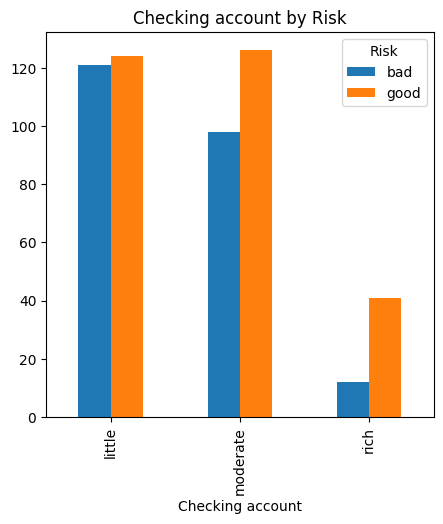

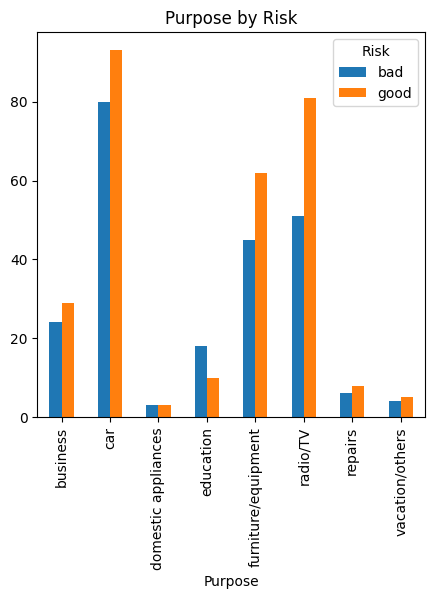

In [29]:
for col in cat_cols:
    df.groupby([col, 'Risk']).size().unstack().plot(kind='bar', figsize=(5, 5), title=f'{col} by Risk')
    plt.show()

In [30]:
df.columns

Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

In [31]:
features=['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose']

In [32]:
target='Risk'

In [36]:
df_model=df[features+[target]]

In [37]:
df_model.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,22,female,2,own,little,moderate,5951,48,radio/TV,bad
1,45,male,2,free,little,little,7882,42,furniture/equipment,good
2,53,male,2,free,little,little,4870,24,car,bad
3,35,male,3,rent,little,moderate,6948,36,car,good
4,28,male,3,own,little,moderate,5234,30,car,bad


In [38]:
from sklearn.preprocessing import LabelEncoder
import joblib

In [40]:
cat_cols=df_model.select_dtypes(include='object').columns.drop('Risk')

In [41]:
le_dict={
}

In [42]:
for col in cat_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    le_dict[col] = le
    joblib.dump(le, f"{col}_encoder.pkl")

In [43]:
le_target=LabelEncoder()

In [44]:
target

'Risk'

In [45]:
df_model[target]=le_target.fit_transform(df_model[target])

In [46]:
df_model[target].value_counts()

,count
Risk,
1,291
0,231


In [47]:
joblib.dump(le_target,'target_encoder.pkl')

['target_encoder.pkl']

In [48]:
df_model.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,22,0,2,1,0,1,5951,48,5,0
1,45,1,2,0,0,0,7882,42,4,1
2,53,1,2,0,0,0,4870,24,1,0
3,35,1,3,2,0,1,6948,36,1,1
4,28,1,3,1,0,1,5234,30,1,0


In [49]:
from sklearn.model_selection import train_test_split

In [55]:
X=df_model.drop(target,axis=1)
X

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
0,22,0,2,1,0,1,5951,48,5
1,45,1,2,0,0,0,7882,42,4
2,53,1,2,0,0,0,4870,24,1
3,35,1,3,2,0,1,6948,36,1
4,28,1,3,1,0,1,5234,30,1
...,...,...,...,...,...,...,...,...,...
517,48,1,1,1,0,1,1743,24,5
518,30,1,3,1,0,0,3959,36,4
519,40,1,3,1,0,0,3857,30,1
520,23,1,2,0,0,0,1845,45,5


In [54]:
y=df_model[target]
y

,Risk
0,0
1,1
2,0
3,1
4,0
...,...
517,1
518,1
519,1
520,0


In [56]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,stratify=y,random_state=1)

In [58]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,ExtraTreesClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV

In [59]:
def train_model(model,param_grid,X_train,y_train,X_test,y_test):
  grid=GridSearchCV(model,param_grid,cv=5,scoring='accuracy',n_jobs=-1)
  grid.fit(X_train,y_train)
  best_model=grid.best_estimator_
  y_pred=best_model.predict(X_test)
  acc=accuracy_score(y_test,y_pred)
  return best_model,acc,grid.best_params_

In [60]:
dt=DecisionTreeClassifier(random_state=1,class_weight='balanced')
dt_param_grid={
 'max_depth':[3,5,7,10,None],
 'min_samples_split':[2,5,10],
 'min_samples_leaf':[1,2,4]
}

In [61]:
best_dt,acc_dt,params_dt=train_model(dt,dt_param_grid,X_train,y_train,X_test,y_test)

In [62]:
print('Decision Tree Accuracy',acc_dt)

Decision Tree Accuracy 0.5904761904761905


In [63]:
print('Best parameters',params_dt)

Best parameters {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 10}


In [64]:
rf=RandomForestClassifier(random_state=1,class_weight='balanced',n_jobs=-1)

In [66]:
rf_param_grid={
    'n_estimators':[100,200],
    'max_depth':[5,7,10,None],
    'min_samples_split':[2,5,10],
    'min_samples_leaf':[1,2,4]
}

In [67]:
best_rf,acc_rf,params_rf=train_model(rf,rf_param_grid,X_train,y_train,X_test,y_test)

In [68]:
print('Random Forest Accuracy',acc_rf)

Random Forest Accuracy 0.638095238095238


In [69]:
print('Best_params',params_rf)

Best_params {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}


In [77]:
et=ExtraTreesClassifier(random_state=1,class_weight='balanced',n_jobs=-1)

In [78]:
et_param_grid={
    'n_estimators':[100,200],
    'max_depth':[5,7,10,None],
    'min_samples_split':[2,5,10],
    'min_samples_leaf':[1,2,4]
}

In [80]:
best_et,acc_et,params_et=train_model(et,et_param_grid,X_train,y_train,X_test,y_test)

In [81]:
print('Extra tress accuracy',acc_et)

Extra tress accuracy 0.638095238095238


In [82]:
print('Best params:',params_et)

Best params: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


In [71]:
xgb=XGBClassifier(random_state=1,
                  scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(),
                  use_label_encoder=False,
                  eval_metric='logloss')

In [72]:
xgb_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.1, 0.2],
    "subsample": [0.7, 1],
    "colsample_bytree": [0.7, 1]
}

In [73]:
best_xgb,acc_xgb,params_xgb=train_model(xgb,xgb_param_grid,X_train,y_train,X_test,y_test)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:21:16] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [74]:
print('XGB accuracy',acc_xgb)

XGB accuracy 0.6476190476190476


In [75]:
print('Best params',params_xgb)

Best params {'colsample_bytree': 1, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.7}


In [83]:
best_et.predict(X_test)

array([1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1,
       1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0,
       0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1,
       1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1])

In [84]:
joblib.dump(best_et,'extra_tress_credit_model.apk')

['extra_tress_credit_model.apk']

In [109]:
pip install streamlit

In [108]:
import streamlit as st
import pandas as pd
import joblib

# Load model
model = joblib.load("extra_tress_credit_model.pkl")

# Load encoders
encoders = {
    col: joblib.load(f"{col}_encoder.pkl")
    for col in ['Sex', 'Housing', 'Saving accounts', 'Checking account']
}

# App UI
st.title("Credit Risk Prediction App")
st.write("Enter applicant information to predict credit risk.")

# User inputs
age = st.number_input("Age", min_value=18, max_value=100, value=30)

sex = st.selectbox("Sex", ['male', 'female'])

job = st.number_input("Job (0-3)", min_value=0, max_value=3, value=1)

housing = st.selectbox("Housing", ['own', 'rent', 'free'])

saving_accounts = st.selectbox(
    "Saving Accounts",
    ['little', 'moderate', 'rich', 'quite rich']
)

checking_account = st.selectbox(
    "Checking Account",
    ['little', 'moderate', 'rich']
)

credit_amount = st.number_input(
    "Credit Amount",
    min_value=0,
    value=1000
)

duration = st.number_input(
    "Duration (months)",
    min_value=1,
    value=12
)

# Prepare input dataframe
input_df = pd.DataFrame({
    'Age': [age],
    'Sex': [encoders["Sex"].transform([sex])[0]],
    'Job': [job],
    'Housing': [encoders["Housing"].transform([housing])[0]],
    'Saving accounts': [encoders["Saving accounts"].transform([saving_accounts])[0]],
    'Checking account': [encoders["Checking account"].transform([checking_account])[0]],
    'Credit amount': [credit_amount],
    'Duration': [duration]
})

# Prediction
if st.button("Predict Risk"):
    pred = model.predict(input_df)[0]

    if pred == 1:
        st.success("The predicted credit risk is: GOOD")
    else:
        st.error("The predicted credit risk is: BAD")

2026-05-18 11:07:29.551 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-18 11:07:29.552 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-18 11:07:29.557 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-18 11:07:29.560 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-18 11:07:29.560 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-18 11:07:29.562 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-18 11:07:29.566 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-18 11:07:29.569 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar